### Single Neuron for **binary classification** using PyTorch

We will build the *simplest* possible classifier: **one** `nn.Linear` layer.


In order to build a deep learning pipeline we need to:

- Preprocess and load data
- Define model: Create a sequential model, specify the number of hidden layers in the neural network, their size and the input and output size.
- Choose loss and optimizer
- Fit model: This is the training step of the neural network.

In [1]:
import torch
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)


### The problem we will solve: classify **Healthy** vs **Not Healthy**

We'll use **dummy (synthetic)** data with two features.


**Features** — the input(s) to our model (e.g., BMI and Blood Pressure).

**Label** — `1` means *Healthy*, `0` means *Not Healthy*.


#### Create the (dummy) dataset

We'll create two clusters of points in 2D:
- Healthy (label=1)
- Not Healthy (label=0)


X shape: torch.Size([200, 2])
y shape: torch.Size([200, 1])


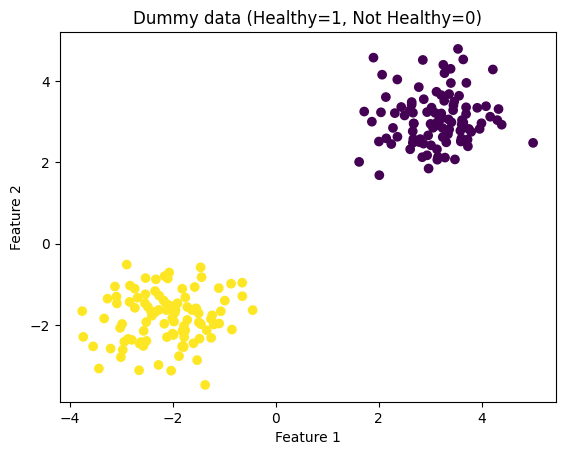

In [12]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

n_per_class = 100

# Class 1: Healthy (centered at (-2, -2))
X_healthy = torch.randn(n_per_class, 2) * 0.7 + torch.tensor([-2.0, -2.0]) # Shape = (100, 2), 100 people and 2 features per person BMI and Blood Pressure
y_healthy = torch.ones(n_per_class, 1) # Shape = (100, 1), 100 rows for each person and each row is a label, so here the label is 1 which is what we consider the model to output for healthy people

# Class 0: Not Healthy (centered at (3, 3))
X_not = torch.randn(n_per_class, 2) * 0.7 + torch.tensor([3.0, 3.0]) # Shape = (100, 2), 100 people and 2 features per person BMI and Blood Pressure
y_not = torch.zeros(n_per_class, 1) # Shape = (100, 1), 100 rows for each person and each row is a label, so here the label is 0 which is what we consider the model to output for non healthy people

# Combine the two classes
X = torch.cat([X_healthy, X_not], dim=0)# Shape = (200, 2) stacking the examples on top of each other to create the whole dataset
y = torch.cat([y_healthy, y_not], dim=0) # Shape = (200, 1) stacking the labels on top of each other to create the labels of the dataset

print("X shape:", X.shape)
print("y shape:", y.shape)

# Visualize
plt.figure()
plt.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=y.squeeze().numpy())
plt.title("Dummy data (Healthy=1, Not Healthy=0)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


#### Create the model

This network will require only **one layer with one neuron**.


In [3]:
# Single perceptron (a 2→1 linear layer)
model = torch.nn.Linear(in_features=2, out_features=1)


_Note:_ We keep the model as **only one** `nn.Linear` layer (a single perceptron).


#### Create the loss function and optimizer


We will use:
- **MSE** (Mean Squared Error) as the loss
- **SGD** (Stochastic Gradient Descent) as the optimizer

Even though classification is often trained with other losses, we keep this notebook **very basic** as requested.


In [4]:
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)


#### Train the model

We will:
1. Compute logits using the linear layer
2. Convert logits → probabilities with `sigmoid`
3. Compute MSE loss between probabilities and labels


**epochs** : number of training iterations


In [5]:
losses = []
accuracies = []
epochs = 200

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    logits = model(X)                  # (N, 1)
    probs = torch.sigmoid(logits)      # (N, 1) in [0,1]

    loss = loss_fn(probs, y)

    loss.backward()
    optimizer.step()

    # Track metrics
    with torch.no_grad():
        preds = (probs >= 0.5).float()
        acc = (preds == y).float().mean().item()

    losses.append(loss.item())
    accuracies.append(acc)

print("Finished training the model")
print("Final loss:", losses[-1])
print("Final accuracy:", accuracies[-1])


Finished training the model
Final loss: 0.0035393214784562588
Final accuracy: 1.0


#### Visualize the training


We will plot:
- Loss vs epoch
- Accuracy vs epoch


In [6]:
history = {"loss": losses, "accuracy": accuracies}
print(history.keys())


dict_keys(['loss', 'accuracy'])


Plots:


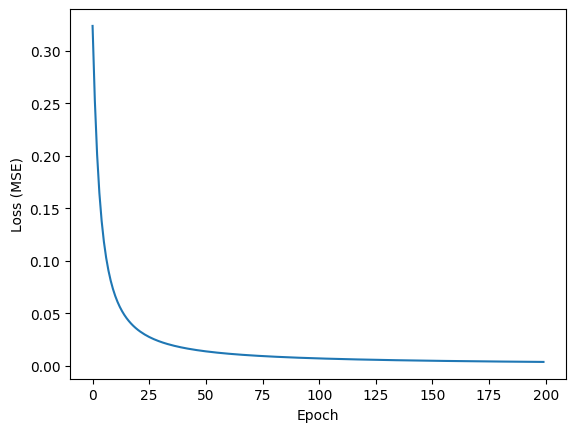

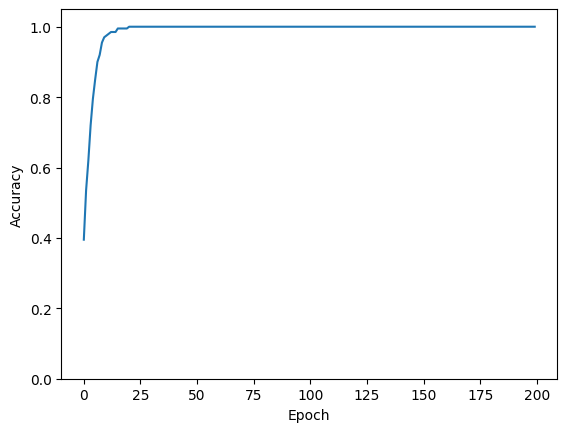

In [7]:
plt.figure()
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.plot(history["loss"])
plt.show()

plt.figure()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.plot(history["accuracy"])
plt.ylim(0, 1.05)
plt.show()


You should see the loss decreasing and the accuracy increasing as training progresses.


#### Visualize the learned decision boundary

Because we used **2 features**, we can draw the separating boundary learned by the single neuron.


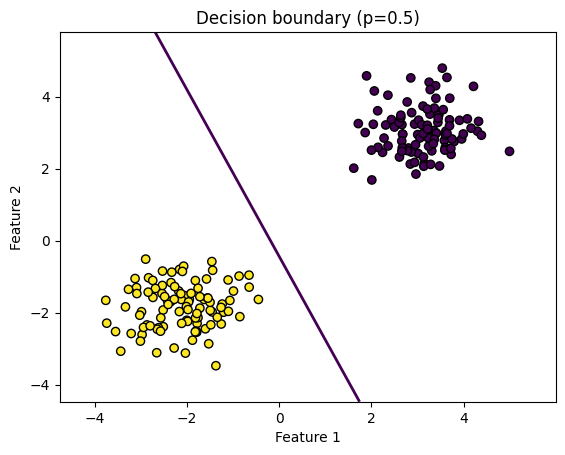

In [8]:
# Create a grid of points
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = torch.meshgrid(
    torch.linspace(x_min, x_max, 200),
    torch.linspace(y_min, y_max, 200),
    indexing="ij",
)
grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

with torch.no_grad():
    grid_probs = torch.sigmoid(model(grid)).reshape(xx.shape)

plt.figure()
plt.contour(xx.numpy(), yy.numpy(), grid_probs.numpy(), levels=[0.5], linewidths=2)
plt.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=y.squeeze().numpy(), edgecolors="k")
plt.title("Decision boundary (p=0.5)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


#### Test the model on a new sample


In [9]:
# Example new patient features (Feature1, Feature2)
x_new = torch.tensor([[1.0, 1.0]], dtype=torch.float32)

with torch.no_grad():
    prob_healthy = torch.sigmoid(model(x_new)).item()
    pred_label = 1 if prob_healthy >= 0.5 else 0

print("P(Healthy) =", prob_healthy)
print("Predicted label =", pred_label, "(1=Healthy, 0=Not Healthy)")


P(Healthy) = 0.14189358055591583
Predicted label = 0 (1=Healthy, 0=Not Healthy)


#### Show the final weights of the model


In [10]:
w = model.weight.detach().cpu()
b = model.bias.detach().cpu()
print(f"weight = {w}")
print(f"bias   = {b}")


weight = tensor([[-1.1119, -0.4801]])
bias   = tensor([-0.2077])
